In [2]:
!pip uninstall numpy -y

Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4


In [3]:
!pip install -q ultralytics numpy==1.24.2 fvcore

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 2.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.3/17.3 MB 25.0 MB/s eta 0:00:0000:0100:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 42.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 30.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 100.2 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 89.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 37.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB

In [ ]:
from torch.utils.data import Dataset, DataLoader
import torch
import os
import cv2
import numpy as np
import json
from collections import defaultdict, OrderedDict
from pathlib import Path
from PIL import Image
import gdown
import sys
import random
import time
import string
from utils.transforms import convert_box_format, check_and_refine_valid_box
from utils.visualize import overlay, draw_polygon
from tqdm import tqdm 
from fvcore.nn import FlopCountAnalysis, parameter_count
from argparse import Namespace 
device = "cuda" if torch.cuda.is_available() else "cpu"
import warnings
import matplotlib.pyplot as plt
%matplotlib inline

warnings.filterwarnings('ignore', category=DeprecationWarning)

if not hasattr(np, 'bool'):
    np.bool = bool


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)               # CPU
    torch.cuda.manual_seed(seed)          # GPU
    torch.cuda.manual_seed_all(seed)      # Multi-GPU (nếu có)

    # For deterministic behavior
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

/tmp/ipykernel_47/378315533.py:29: FutureWarning: In the future `np.bool` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, 'bool'):


In [6]:
class SignboardText(Dataset):
    def __init__(self, image_data, annotation_data, transforms=None, TextInstance=None, Sample=None, method=None):
        self.image_data = image_data

        self.image_list = os.listdir(image_data)
        self.annotation_lookup = self.read_json(annotation_data)
        self.transforms = transforms 
        self.TextInstance = TextInstance
        self.Sample = Sample
        self.method = method

    def read_json(self, file): 
        with open(file, 'r') as file: 
            data = json.load(file)

        # Create mapping: id images and image_id annotations
        annotations_lookup = defaultdict(list)
        for info in data['annotations']:
            annotations_lookup[info['image_id']].append(info)

        return annotations_lookup

    def extract_info(self, info):
        labels = []
        for p in info:
            object = {}
            bbox = p['bbox']
            seg = p['segmentation']
            transcript = p['transcription']

            object['bbox'] = bbox
            object['segmentation'] = seg
            object['transcription'] = transcript

            labels.append(object)

        return labels

    def __len__(self):
        return len(self.image_list)
    
    def __getitem__(self, index):
        image_name = self.image_list[index]
        image_id = os.path.join(Path(self.image_data).name, image_name)
        image_path = os.path.join(self.image_data, image_name)
        info = self.annotation_lookup.get(image_id)
        if info is not None: labels = self.extract_info(info)
        else: 
            print(image_path)
            labels = None 

        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image_height, image_width = image.shape[:2]
        gt = {
            'orig_image': image,
            'file_name': image_id, 
            'image_size': image.shape[:2],
        }
        polygons, transcriptions = [], []
        if labels is not None: 
            for i, label in enumerate(labels): 
                segmentation = label['segmentation']
                transcription = label['transcription']
                bbox = label['bbox']
                new_bbox = check_and_refine_valid_box(bbox, image_width, image_height)
                if new_bbox is None: continue
                polygons.append(segmentation)
                transcriptions.append(transcription)
                # polygons.append(self.TextInstance(segmentation, 'c', transcription))

        if self.transforms is not None:
            if self.method == 'units':
                sample = self.Sample(image_size=image.shape[:2])
                image, _ = self.transforms(Image.fromarray(image), sample)
            if self.method == 'textpms': 
                image, _ = self.transforms(image, polygons=None)

            if self.method == 'dbnet': 
                data = dict(image=image)
                image, shape_list = self.transforms(data)
                gt['shape_list'] = shape_list
            if self.method == 'fast': 
                image = self.transforms(image)
            
        if image.shape[-1] == 3: 
            image = image.transpose(2, 0, 1) # C, H, W

        if not isinstance(image, torch.Tensor):
            image = torch.from_numpy(image)
            
        gt['image'] = image
        gt['polygons'] = torch.from_numpy(np.array([polygon for polygon in polygons],
                                                  dtype=np.int32))
        gt['transcriptions'] = [transcription for transcription in transcriptions]

        return gt

In [ ]:
PRED_ICDAR = 'Prediction_ICDAR'
PRED_TOTAL = 'Prediction_TOTAL'

def create_folder(folder): 
    if not Path(folder).is_dir():
        Path(folder).mkdir(parents=True, exist_ok=True)

def rescale_box(image, orig_size, boxes=None):
    assert len(image.shape) == 4
    original_height, original_width = orig_size
    transformed_height, transformed_width = image.shape[2:] # B, C, H, W
    ratio = [original_width / transformed_width, original_height / transformed_height]

    if boxes is not None: 
        boxes = [np.round(box * ratio).astype(np.int32) for box in boxes] 

    return boxes

def save_output_txt(file_name, polygons, pred_transcriptions, confidences=None, boxes=None, contours=None): 
    sub_folder, file = Path(file_name).parent, Path(file_name).with_suffix('.txt').name
    pred_icdar_folder = os.path.join(PRED_ICDAR, sub_folder)
    pred_total_folder = os.path.join(PRED_TOTAL, sub_folder)

    create_folder(pred_icdar_folder)
    create_folder(pred_total_folder)

    pred_icdar_file = os.path.join(pred_icdar_folder, file)
    pred_total_file = os.path.join(pred_total_folder, file)
    if len(polygons) > 0: 
        if boxes is not None: 
            with open(pred_icdar_file, 'w', encoding='utf-8') as f: 
                for box, transcription, conf in zip(boxes, pred_transcriptions, confidences): 
                    line = box.flatten()
                    f.write(','.join(map(str, line))  + f',{conf:.2f}' + f',{transcription}' + '\n')

        if contours is not None: 
            with open(pred_total_file, 'w', encoding='utf-8') as f: 
                for contour, transcription, conf in zip(contours, pred_transcriptions, confidences): 
                    line = contour.flatten()
                    f.write(','.join(map(str, line)) + f',{conf:.2f}' + f',{transcription}' + '\n')

def get_state_dict(state_dict, idx): 
    new_state_dict = OrderedDict()
    for k, v in state_dict.items(): 
        new_k = k[idx:] 
        new_state_dict[new_k] = v

    return new_state_dict

def data_transfer_ICDAR(contours):
    cnts = list()
    for cont in contours:
        rect = cv2.minAreaRect(cont)
        if min(rect[1][0], rect[1][1]) <=8 :
            continue
        #rect=(rect[0],(rect[1][0]-3, rect[1][1]-3), rect[2])
        points = cv2.boxPoints(rect)
        points = np.int0(points)
        # print(points.shape)
        # points = np.reshape(points, (4, 2))
        cnts.append(points)
    return cnts

In [ ]:
def measure_fps(model, image, num_runs=100):
    model.eval()
    # Warm-up
    with torch.inference_mode():
        for _ in range(10):
            _ = model(image)
    
    # Measure FPS
    torch.cuda.synchronize()
    start = time.time()
    
    with torch.inference_mode():
        for _ in range(num_runs):
            _ = model(image)
            
    torch.cuda.synchronize()
    end = time.time()
    
    avg_time = (end - start) / num_runs
    fps = 1 / avg_time
    
    print(f"Average time per frame: {avg_time*1000:.2f} ms")
    
    return fps

def measure_flops(model, image): 
    flops = FlopCountAnalysis(model, image).total() / 1e9
    return flops

def measure_params(model): 
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad) / 1e6
    non_trainable = sum(p.numel() for p in model.parameters() if not p.requires_grad) / 1e6
    total = trainable + non_trainable

    return total, trainable, non_trainable

## Two-Stage STR

In [10]:
!git clone https://github.com/GXYM/TextPMs.git
!git clone https://github.com/Topdu/OpenOCR.git
!git clone https://github.com/frotms/PaddleOCR2Pytorch.git
!git clone https://github.com/czczup/FAST.git

Cloning into 'TextPMs'...
remote: Enumerating objects: 361, done.
remote: Counting objects: 100% (361/361), done.
remote: Compressing objects: 100% (304/304), done.
remote: Total 361 (delta 83), reused 280 (delta 31), pack-reused 0 (from 0)
Receiving objects: 100% (361/361), 3.41 MiB | 25.31 MiB/s, done.
Resolving deltas: 100% (83/83), done.
Cloning into 'OpenOCR'...
remote: Enumerating objects: 2671, done.
remote: Counting objects: 100% (875/875), done.
remote: Compressing objects: 100% (157/157), done.
remote: Total 2671 (delta 755), reused 743 (delta 718), pack-reused 1796 (from 1)
Receiving objects: 100% (2671/2671), 12.35 MiB | 32.84 MiB/s, done.
Resolving deltas: 100% (1731/1731), done.
Cloning into 'PaddleOCR2Pytorch'...
remote: Enumerating objects: 1682, done.
remote: Counting objects: 100% (114/114), done.
remote: Compressing objects: 100% (67/67), done.
remote: Total 1682 (delta 57), reused 48 (delta 47), pack-reused 1568 (from 2)
Receiving objects: 100% (1682/1682), 69.95 Mi

In [ ]:
class TextSpotting(object): 
    def __init__(self, model_det, model_rec, postprocess_det, postprocess_rec,
                transforms_rec, cfg_det, cfg_rec, device, threshold_det=0.5):
        self.model_det = model_det
        self.model_rec = model_rec
        self.postprocess_det = postprocess_det
        self.postprocess_rec = postprocess_rec
        self.transforms_rec = transforms_rec
        self.cfg_det = cfg_det
        self.cfg_det.threshold = threshold_det
        self.device = device
    def detect(self, image, orig_size):
        assert isinstance(image, torch.Tensor)
        self.model_det.eval() 
        # TextPMs 
        b, c, h, w = image.shape
        with torch.inference_mode(): 
            preds, *_ = self.model_det(image)
            preds = torch.sigmoid(preds[0, :, :h//self.cfg_det.scale, :w//self.cfg_det.scale])
            preds = preds.cpu().numpy()

        labels, boxes, polygons = self.postprocess_det(preds, self.cfg_det, self.cfg_det.scale)
        polygons = data_transfer_ICDAR(polygons)
        rescale_polygons = rescale_box(image, orig_size, boxes=polygons)

        return rescale_polygons
    
    def recognize(self, text_image): 
        """
        Args: 
            text_image: images contain word or line
        """
        self.model_rec.eval()
        with torch.inference_mode():
            logits = self.model_rec(text_image)
            post_results = self.postprocess_rec(logits, torch_tensor=True)
            pred, score = post_results[0]
            
        return pred, score
    def __call__(self, orig_image, image):
        assert isinstance(orig_image, np.ndarray)
        assert isinstance(image, torch.Tensor)
        orig_size = orig_image.shape[:2]
        polygons = self.detect(image, orig_size)
        results = {
            'polygons': polygons,
            'text': [],
        }
        scores = []
        for poly in polygons:
            x, y, w, h = cv2.boundingRect(poly.astype(np.int32))
            new_bbox = check_and_refine_valid_box([x, y, w, h], orig_size[1], orig_size[0])
            if new_bbox is None: 
                pred, score = '###', 1.00
            else:  
                x, y, w, h = new_bbox
                sub_image = orig_image[y:y+h, x:x+w]
                transformed_image = self.transforms_rec(Image.fromarray(sub_image)).unsqueeze(dim=0).to(self.device) # B, C, H, W
                pred, score = self.recognize(transformed_image)
            results['text'].append(pred)
            scores.append(score)

        results['score'] = scores

        return results

def collate_fn(batch): 
    return {
        'orig_image': [b['orig_image'] for b in batch],
        'file_name': [b['file_name'] for b in batch],
        'image_size': [b['image_size'] for b in batch],
        'image': torch.stack([b['image'] for b in batch]),
        'polygons': torch.stack([b['polygons'] for b in batch]),
        'transcriptions': [b['transcriptions'] for b in batch]
    }

#### TextPMs

In [12]:
%cd /kaggle/working/TextPMs

/kaggle/working/TextPMs


In [13]:
from util.config import config as config_det, update_config
from network.textnet import TextNet
from util.option import BaseOptions
from util.augmentation import BaseTransform
# from util.detection import watershed_segment
from util.eval import data_transfer_ICDAR
from dataset.dataload import TextInstance
from skimage import segmentation

def fill_hole(input_mask):
    h, w = input_mask.shape
    canvas = np.zeros((h + 2, w + 2), np.uint8)
    canvas[1:h + 1, 1:w + 1] = input_mask.copy()

    mask = np.zeros((h + 4, w + 4), np.uint8)

    cv2.floodFill(canvas, mask, (0, 0), 1)
    canvas = canvas[1:h + 1, 1:w + 1].astype(np.bool)

    return (~canvas | input_mask.astype(np.uint8))

def watershed_segment(preds, cfg, scale=1.0):
    text_region = np.mean(preds[2:], axis=0)
    region = fill_hole(text_region >= cfg.threshold)

    text_kernal = np.mean(preds[0:2], axis=0)
    kernal = fill_hole(text_kernal >= cfg.threshold)

    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    opening = cv2.morphologyEx(kernal, cv2.MORPH_OPEN, kernel, iterations=1)
    kernal = cv2.erode(opening, kernel, iterations=1)  # sure foreground area
    ret, m = cv2.connectedComponents(kernal)

    distance = np.mean(preds[:], axis=0)
    distance = np.array(distance / np.max(distance) * 255, dtype=np.uint8)
    labels = segmentation.watershed(-distance, m, mask=region)
    boxes = []
    contours = []
    small_area = (300 if cfg.test_size[0] >= 256 else 150)
    for idx in range(1, np.max(labels) + 1):
        text_mask = labels == idx
        if np.sum(text_mask) < small_area / (cfg.scale * cfg.scale) \
                or np.mean(preds[-1][text_mask]) < cfg.score_i:  # 150 / 300
            continue
        cont, _ = cv2.findContours(text_mask.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        epsilon = 0.003 * cv2.arcLength(cont[0], True)
        approx = cv2.approxPolyDP(cont[0], epsilon, True)
        contours.append(approx.reshape((-1, 2)) * [scale, scale])

    return labels, boxes, contours

In [14]:
# Download pretrained model
file_id = '1JKVqjZAZs4mckhH7KiC7sNDqUw8Ib1Km'
url_model = f'https://drive.google.com/uc?id={file_id}'

gdown.download(url_model, 'TextPMs_Icdar2015.zip', quiet=False)
!unzip /kaggle/working/TextPMs/TextPMs_Icdar2015.zip

Downloading...
From (original): https://drive.google.com/uc?id=1JKVqjZAZs4mckhH7KiC7sNDqUw8Ib1Km
From (redirected): https://drive.google.com/uc?id=1JKVqjZAZs4mckhH7KiC7sNDqUw8Ib1Km&confirm=t&uuid=88d84ddc-ce43-4ea2-af54-7af3857138a1
To: /kaggle/working/TextPMs/TextPMs_Icdar2015.zip
100%|██████████| 254M/254M [00:04<00:00, 62.4MB/s] 

Archive:  /kaggle/working/TextPMs/TextPMs_Icdar2015.zip
   creating: Icdar2015/
  inflating: Icdar2015/TextPMs_resnet50_370.pth  

In [15]:
option = BaseOptions()
args = option.parser.parse_known_args()
update_config(config_det, args[0])
config_det.device = device
if device == "cpu": 
    config_det.cuda = False

# config_det.threshold = 0.5
# Initialize transform
config_det.test_size = [640, 640]
transforms_det = BaseTransform(size=config_det.test_size, mean=config_det.means, std=config_det.stds)
textpm_model = TextNet(is_training=False, backbone=config_det.net)
checkpoint = torch.load('/kaggle/working/TextPMs/Icdar2015/TextPMs_resnet50_370.pth', map_location=device)
state_dict = checkpoint['model']
textpm_model.load_state_dict(state_dict, strict=True)
textpm_model = textpm_model.to(config_det.device)

#### SVTRv2

In [16]:
%cd /kaggle/working/OpenOCR

/kaggle/working/OpenOCR


In [17]:
from tools.infer_rec import OpenRecognizer
from tools.engine.config import Config

class OpenOCRTransforms(object): 
    def __init__(self, transforms, ops, infer_aug=False):
        self.transforms = transforms
        self.ops = ops
        self.infer_aug = infer_aug
    def __call__(self, img):
        if not self.infer_aug: 
            assert isinstance(img, Image.Image)
        else: 
            if isinstance(img, Image.Image): 
                img = np.array(img)
        inputs = {'image': img}
        img = self.transforms(inputs, self.ops[1:])[0]
        if not isinstance(img, torch.Tensor): 
            img = torch.from_numpy(img)
        return img

In [18]:
# Download pretrained model SVTRv2-B
file_id_model = '1P56B_PVYBF649zUqQFShuAZC1XuNmUcL'
url_model = f'https://drive.google.com/uc?id={file_id_model}'
file_id_config = '1Ds-TilzI_2JIAomKyJS5RFCn-fU-UsOn'
url_config = f'https://drive.google.com/uc?id={file_id_config}'

gdown.download(url_model, 'SVTRv2-B.pth', quiet=False)
gdown.download(url_config, 'svtrv2_smtr_gtc_rctc.yml', quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1P56B_PVYBF649zUqQFShuAZC1XuNmUcL
From (redirected): https://drive.google.com/uc?id=1P56B_PVYBF649zUqQFShuAZC1XuNmUcL&confirm=t&uuid=55729a34-1a3f-4ec2-bec3-6752b21168ca
To: /kaggle/working/OpenOCR/SVTRv2-B.pth
100%|██████████| 84.2M/84.2M [00:02<00:00, 40.3MB/s]
Downloading...
From: https://drive.google.com/uc?id=1Ds-TilzI_2JIAomKyJS5RFCn-fU-UsOn
To: /kaggle/working/OpenOCR/svtrv2_smtr_gtc_rctc.yml
100%|██████████| 4.21k/4.21k [00:00<00:00, 6.92MB/s]


'svtrv2_smtr_gtc_rctc.yml'

In [19]:
config_file_rec = '/kaggle/working/OpenOCR/svtrv2_smtr_gtc_rctc.yml'
config_rec = Config(config_file_rec).cfg
config_rec['Global']['character_dict_path'] = '/kaggle/working/OpenOCR/tools/utils/EN_symbol_dict.txt'
config_rec['PostProcess']['character_dict_path'] = '/kaggle/working/OpenOCR/tools/utils/EN_symbol_dict.txt'
print(f"Model name {config_rec['Architecture']['algorithm']}")

svtrv2 = OpenRecognizer(config_rec)

Model name SVTRv2
[2025/12/12 16:12:02] openrec INFO: train from scratch


In [20]:
svtrv2_checkpoint = torch.load('/kaggle/working/OpenOCR/SVTRv2-B.pth', map_location=device)
print(f"Epoch: {svtrv2_checkpoint['epoch']}")
print(f"Global Step: {svtrv2_checkpoint['global_step']}")

# Load pretrained model's weight
svtrv2.model.load_state_dict(svtrv2_checkpoint['state_dict'], strict=True)
svtrv2.post_process_class.only_gtc = True
transforms_rec = OpenOCRTransforms(svtrv2.transform, svtrv2.ops)
svtrv2.model = svtrv2.model.to(device)

Epoch: 18
Global Step: 114500


In [21]:
%cd ..

/kaggle/working


In [ ]:
e2e_model = TextSpotting(model_det=textpm_model, model_rec=svtrv2.model, postprocess_det=watershed_segment,
                        postprocess_rec=svtrv2.post_process_class, transforms_rec=transforms_rec, cfg_det=config_det,
                        cfg_rec=config_rec, device=device, threshold_det=0.5)

In [23]:
english_ds = SignboardText(image_data='/kaggle/input/signboardtext/original_images/english',
                           annotation_data='/kaggle/input/signboardtext/annotations.json',
                           transforms=transforms_det,
                          method='textpms')
vietsignboard_ds = SignboardText(image_data='/kaggle/input/signboardtext/original_images/vietsignboard',
                               annotation_data='/kaggle/input/signboardtext/annotations.json',
                               transforms=transforms_det,
                                method='textpms')
vin_ds = SignboardText(image_data='/kaggle/input/signboardtext/original_images/vin',
                        annotation_data='/kaggle/input/signboardtext/annotations.json',
                        transforms=transforms_det,
                      method='textpms')
vietsignboard_line = SignboardText(image_data='/kaggle/input/signboardtext/original_images/vietsignboard',
                                   annotation_data='/kaggle/input/signboardtext/annotations_line.json',
                                   transforms=transforms_det,
                                   method='textpms')

In [24]:
viet_dataloader = DataLoader(dataset=vietsignboard_ds, batch_size=1, shuffle=False, collate_fn=collate_fn)
english_dataloader = DataLoader(dataset=english_ds, batch_size=1, shuffle=False, collate_fn=collate_fn)
vin_dataloader = DataLoader(dataset=vin_ds, batch_size=1, shuffle=False, collate_fn=collate_fn)
viet_dataloaderline = DataLoader(dataset=vietsignboard_line, batch_size=1, shuffle=False, collate_fn=collate_fn)

In [76]:
set_seed(42)
for data in tqdm(viet_dataloader): 
    orig_image = data['orig_image'][0]
    file_name, image = data['file_name'][0], data['image'].to(device)
    polygons = data['polygons'][0]
    orig_size = data['image_size'][0]
    transcriptions = data['transcriptions'][0]
    results = e2e_model(orig_image, image)
    
    save_output_txt(file_name, polygons, pred_transcriptions=results['text'], confidences=results['score'],
                   boxes=results['polygons'])

 30%|███       | 359/1194 [06:02<13:45,  1.01it/s]

/kaggle/input/signboardtext/original_images/vietsignboard/milkteastore-11.jpg


 40%|███▉      | 475/1194 [08:01<10:48,  1.11it/s]

/kaggle/input/signboardtext/original_images/vietsignboard/milkteastore-3.jpg


 42%|████▏     | 497/1194 [08:21<11:07,  1.04it/s]

...

 50%|█████     | 597/1194 [10:11<10:14,  1.03s/it]

/kaggle/input/signboardtext/original_images/vietsignboard/milkteastore-46.jpg


 52%|█████▏    | 623/1194 [10:37<10:22,  1.09s/it]

/kaggle/input/signboardtext/original_images/vietsignboard/milkteastore-5.jpg


100%|██████████| 1194/1194 [20:25<00:00,  1.03s/it]


In [28]:
set_seed(42)
for data in tqdm(english_dataloader): 
    orig_image = data['orig_image'][0]
    file_name, image = data['file_name'][0], data['image'].to(device)
    polygons = data['polygons'][0]
    orig_size = data['image_size'][0]
    transcriptions = data['transcriptions'][0]
    results = e2e_model(orig_image, image)
    
    save_output_txt(file_name, polygons, pred_transcriptions=results['text'], confidences=results['score'],
                   boxes=results['polygons'])

100%|██████████| 413/413 [03:52<00:00,  1.78it/s]


In [79]:
set_seed(42)
for data in tqdm(vin_dataloader): 
    orig_image = data['orig_image'][0]
    file_name, image = data['file_name'][0], data['image'].to(device)
    polygons = data['polygons'][0]
    orig_size = data['image_size'][0]
    transcriptions = data['transcriptions'][0]
    results = e2e_model(orig_image, image)
    
    save_output_txt(file_name, polygons, pred_transcriptions=results['text'], confidences=results['score'],
                   boxes=results['polygons'])

100%|██████████| 516/516 [07:04<00:00,  1.21it/s]


In [83]:
set_seed(42)
for data in tqdm(viet_dataloaderline): 
    orig_image = data['orig_image'][0]
    file_name, image = data['file_name'][0], data['image'].to(device)
    polygons = data['polygons'][0]
    orig_size = data['image_size'][0]
    transcriptions = data['transcriptions'][0]
    results = e2e_model(orig_image, image)
    
    save_output_txt(file_name, polygons, pred_transcriptions=results['text'], confidences=results['score'],
                   boxes=results['polygons'])

  3%|▎         | 36/1194 [00:35<16:48,  1.15it/s]

/kaggle/input/signboardtext/original_images/vietsignboard/levansy-60.jpg


  3%|▎         | 40/1194 [00:42<30:26,  1.58s/it]

/kaggle/input/signboardtext/original_images/vietsignboard/else-135.jpg


  3%|▎         | 41/1194 [00:44<29:00,  1.51s/it]

...

 99%|█████████▉| 1183/1194 [20:48<00:11,  1.02s/it]

/kaggle/input/signboardtext/original_images/vietsignboard/levansy-12.jpg


100%|█████████▉| 1193/1194 [20:58<00:01,  1.03s/it]

/kaggle/input/signboardtext/original_images/vietsignboard/else-118.jpg


100%|██████████| 1194/1194 [21:00<00:00,  1.06s/it]


In [25]:
set_seed(seed=42) 
num_runs = 110
list_orig_image, list_image = [], []
for i, data in enumerate(english_dataloader):
    if i == num_runs: break
    orig_image = data['orig_image'][0]
    file_name, image = data['file_name'][0], data['image'].to(device)
    list_orig_image.append(orig_image)
    list_image.append(image)

fps = measure_fps_two_stage(e2e_model, list_orig_image, list_image)
total_params = measure_params(e2e_model.model_det)[0] + measure_params(e2e_model.model_rec)[0]
print('---------TextPMs + SVTRv2---------')
print(f'FPS: {fps:.2f}')
print(f'Total Params: {total_params:.2f}')

Average time per frame: 181.07 ms
---------TextPMs + SVTRv2---------
FPS: 5.52
Total Params: 57.45


In [25]:
set_seed(seed=42) 
num_runs = 110
list_orig_image, list_image = [], []
for i, data in enumerate(english_dataloader):
    if i == num_runs: break
    orig_image = data['orig_image'][0]
    file_name, image = data['file_name'][0], data['image'].to(device)
    list_orig_image.append(orig_image)
    list_image.append(image)

fps = measure_fps_two_stage(e2e_model, list_orig_image, list_image)
total_params = measure_params(e2e_model.model_det)[0] + measure_params(e2e_model.model_rec)[0]
print('---------TextPMs + SVTRv2---------')
print(f'FPS: {fps:.2f}')
print(f'Total Params: {total_params:.2f}')

Average time per frame: 181.83 ms
---------TextPMs + SVTRv2---------
FPS: 5.50
Total Params: 57.45


In [ ]:
!zip -r prediction_icdar.zip /kaggle/working/Prediction_ICDAR

In [22]:
set_seed(seed=42)
image = cv2.imread('/kaggle/input/signboardtext/images/train/vietsignboard/levansy-86.jpg')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
transformed_image, _ = transforms_det(image)
transformed_image = torch.from_numpy(transformed_image.transpose(2, 0, 1)).unsqueeze(dim=0).to(device)
results = e2e_model(image, transformed_image)

In [61]:
set_seed(seed=42)
image = cv2.imread('/kaggle/input/signboardtext/images/train/vietsignboard/levansy-86.jpg')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

data = dict(image = image)
transformed_image, shape_list = transforms(data)
if isinstance(transformed_image, np.ndarray): 
    transformed_image = torch.from_numpy(transformed_image)
shape_list = np.expand_dims(shape_list, axis=0)

results = e2e_model(image, transformed_image.unsqueeze(dim=0).to(device), shape_list)

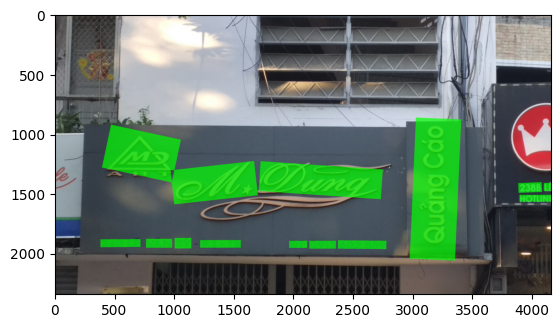

In [62]:
mask = np.zeros(image.shape[:2], np.uint8)
fill_mask = cv2.fillPoly(mask, results['polygons'].astype(np.int32), color=1)
prediction = overlay(image, fill_mask, color=(0, 255, 0), alpha=0.7)
plt.imshow(prediction)
plt.show()

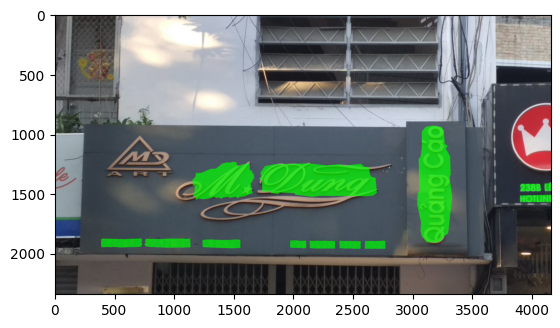

In [46]:
mask = np.zeros(image.shape[:2], np.uint8)
fill_mask = cv2.fillPoly(mask, results['polygons'], color=1)
prediction = overlay(image, fill_mask, color=(0, 255, 0), alpha=0.7)
plt.imshow(prediction)
plt.show()

## One-Stage STR

In [10]:
def collate_fn(batch): 
    return {
        'file_name': [b['file_name'] for b in batch],
        'image_size': [b['image_size'] for b in batch],
        'image': torch.stack([b['image'] for b in batch]),
        'polygons': [b['polygons'] for b in batch],
        'transcriptions': [b['transcriptions'] for b in batch]
    }

### Units

In [11]:
!git clone https://github.com/clovaai/units.git

Cloning into 'units'...
remote: Enumerating objects: 112, done.
remote: Counting objects: 100% (4/4), done.
remote: Compressing objects: 100% (4/4), done.
remote: Total 112 (delta 0), reused 0 (delta 0), pack-reused 108 (from 1)
Receiving objects: 100% (112/112), 27.84 MiB | 35.54 MiB/s, done.
Resolving deltas: 100% (10/10), done.


In [12]:
%cd /kaggle/working/units

/kaggle/working/units


In [13]:
!pip install -q pydantic==1.9.0 tensorfn==0.1.23 lmdb

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.8/121.8 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.3/140.3 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.1/295.1 kB 15.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sigstore 4.1.0 requires pydantic<3,>=2, but you have pydantic 1.9.0 which is incompatible.
sigstore-models 0.0.5 requires pydantic>=2.11.7, but you have pydantic 1.9.0 which is incompatible.
sigstore-rekor-types 0.0.18 requires pydantic[email]<3,>=2, but you have pydantic 1.9.0 which is incompatible.
google-adk 1.18.0 requires pydantic<3.0.0,>=2.0, but you have pydantic 1.9.0 which is incompatible.
ydata-profiling 4.17.0 requires pydantic>=2, but you have pydantic 1.9.0 which is incompatible.
a2a-sdk

In [14]:
from units.config import E2EConfig
from tensorfn.config import instantiate, Config
from tensorfn import load_config
from units.transform import Compose
from units.structures import Sample
from units.dataset import MultitaskCollator
import torch.distributed as dist

def rescale_box(image, orig_size, boxes=None, contours=None):
    assert len(image.shape) == 4
    original_height, original_width = orig_size
    transformed_height, transformed_width = image.shape[2:] # B, C, H, W
    ratio = max(original_height, original_width) / max(transformed_height, transformed_width)

    if boxes is not None: 
        boxes = [np.round(box * ratio).astype(np.int32) for box in boxes] 
    if contours is not None: 
        contours = [np.round(contour * ratio).astype(np.int32) for contour in contours]

    return boxes, contours

def inference(model, inputs, mapper, orig_size): 
    model.eval() 
    with torch.inference_mode(): 
        outputs = model(inputs)
    
    results = mapper.postprocess(inputs, outputs)
    boxes, transcriptions, confidences = [], [], []
    for result, size in zip(results, orig_size): 
        rescaled_box, _ = rescale_box(inputs.images, size, boxes=torch.stack(result.coords, 0).numpy())
        boxes.append(rescaled_box)
        transcriptions.append(result.texts)
        confidences.append(result.confidences)

    return boxes, transcriptions, confidences

In [15]:
# Download pretrained model
file_id = '1c76n9QvysA30q31KMzrDoa7I9bqLuBSa'
url_model = f'https://drive.google.com/uc?id={file_id}'

gdown.download(url_model, 'units.pt', quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1c76n9QvysA30q31KMzrDoa7I9bqLuBSa
From (redirected): https://drive.google.com/uc?id=1c76n9QvysA30q31KMzrDoa7I9bqLuBSa&confirm=t&uuid=24e3cb8b-e6d2-4d5b-b14c-f8520a35ef12
To: /kaggle/working/units/units.pt
100%|██████████| 1.21G/1.21G [00:12<00:00, 100MB/s] 


'units.pt'

In [16]:
cfg = load_config(E2EConfig, config='/kaggle/working/units/configs/ic15.py', show=False)
checkpoint = torch.load('/kaggle/working/units/units.pt', map_location=device)
state_dict = checkpoint['model']
new_state_dict = get_state_dict(state_dict, idx=7)
cfg.model['__args'][2]['__args'][0]['pretrained'] = False
cfg.n_gpu = torch.cuda.device_count()

units_model = instantiate(cfg.model).to(device)
cfg.distributed = True if cfg.n_gpu > 1 else False

if cfg.distributed: 
    units_model = torch.nn.DataParallel(units_model, device_ids=[0, 1])

# Load state dict
if cfg.n_gpu > 1: 
    units_model.load_state_dict(state_dict, strict=True)
else: 
    units_model.load_state_dict(new_state_dict, strict=True)

/usr/local/lib/python3.11/dist-packages/torch/functional.py:539: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:3637.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


In [28]:
transforms = Compose(instantiate(cfg.evaluate.transform))
mapper = instantiate(cfg.training.mappers)[0]
collator = MultitaskCollator([], evaluate=True)

In [29]:
english_ds = SignboardText(image_data='/kaggle/input/signboardtext/original_images/english',
                           annotation_data='/kaggle/input/signboardtext/annotations.json',
                           transforms=transforms,
                           Sample=Sample,
                          method='units')
vietsignboard_ds = SignboardText(image_data='/kaggle/input/signboardtext/original_images/vietsignboard',
                               annotation_data='/kaggle/input/signboardtext/annotations.json',
                               transforms=transforms,
                                 Sample=Sample,
                                method='units')
vin_ds = SignboardText(image_data='/kaggle/input/signboardtext/original_images/vin',
                        annotation_data='/kaggle/input/signboardtext/annotations.json',
                        transforms=transforms,
                       Sample=Sample,
                      method='units')
vietsignboard_line = SignboardText(image_data='/kaggle/input/signboardtext/original_images/vietsignboard',
                                   annotation_data='/kaggle/input/signboardtext/annotations_line.json',
                                   transforms=transforms,
                                   Sample=Sample,
                                   method='units')

In [30]:
viet_dataloader = DataLoader(dataset=vietsignboard_ds, batch_size=4, shuffle=False, collate_fn=collate_fn)
english_dataloader = DataLoader(dataset=english_ds, batch_size=4, shuffle=False, collate_fn=collate_fn)
vin_dataloader = DataLoader(dataset=vin_ds, batch_size=4, shuffle=False, collate_fn=collate_fn)
viet_dataloaderline = DataLoader(dataset=vietsignboard_line, batch_size=4, shuffle=False, collate_fn=collate_fn)

In [20]:
set_seed(42)
for data in tqdm(viet_dataloader): 
    file_name, image = data['file_name'], data['image']
    polygons = data['polygons']
    orig_size = data['image_size']
    transcriptions = data['transcriptions']
    B, C, H, W = image.shape
    
    samples = [Sample(image_size=(H, W)) for _ in range(B)]
    
    inputs = collator(list(zip(image, samples)))
    inputs = inputs.to(device)

    qboxes, pred_transcriptions, confidences = inference(units_model, inputs, mapper, orig_size)
    for file, polygon, pred_transcription, confidence, qbox in zip(file_name, polygons, 
                                                                  pred_transcriptions, confidences, qboxes):
        save_output_txt(file, polygon, pred_transcription, confidences=confidence, boxes=qbox)

 30%|██▉       | 89/299 [34:28<1:09:37, 19.89s/it]

/kaggle/input/signboardtext/original_images/vietsignboard/milkteastore-11.jpg


 39%|███▉      | 118/299 [44:05<55:17, 18.33s/it]  

/kaggle/input/signboardtext/original_images/vietsignboard/milkteastore-3.jpg


 41%|████▏     | 124/299 [46:11<58:55, 20.20s/it]  

...

 50%|████▉     | 149/299 [58:46<1:44:08, 41.65s/it]

/kaggle/input/signboardtext/original_images/vietsignboard/milkteastore-46.jpg


 52%|█████▏    | 155/299 [1:00:42<57:24, 23.92s/it]  

/kaggle/input/signboardtext/original_images/vietsignboard/milkteastore-5.jpg


100%|██████████| 299/299 [1:56:50<00:00, 23.45s/it]


In [24]:
set_seed(42)
for data in tqdm(english_dataloader): 
    file_name, image = data['file_name'], data['image']
    polygons = data['polygons']
    orig_size = data['image_size']
    transcriptions = data['transcriptions']
    B, C, H, W = image.shape
    
    samples = [Sample(image_size=(H, W)) for _ in range(B)]
    
    inputs = collator(list(zip(image, samples)))
    inputs = inputs.to(device)

    qboxes, pred_transcriptions, confidences = inference(units_model, inputs, mapper, orig_size)
    for file, polygon, pred_transcription, confidence, qbox in zip(file_name, polygons, 
                                                                  pred_transcriptions, confidences, qboxes):
        save_output_txt(file, polygon, pred_transcription, confidences=confidence, boxes=qbox)

100%|██████████| 104/104 [14:29<00:00,  8.36s/it]


In [27]:
set_seed(42)
for data in tqdm(vin_dataloader): 
    file_name, image = data['file_name'], data['image']
    polygons = data['polygons']
    orig_size = data['image_size']
    transcriptions = data['transcriptions']
    B, C, H, W = image.shape
    
    samples = [Sample(image_size=(H, W)) for _ in range(B)]
    
    inputs = collator(list(zip(image, samples)))
    inputs = inputs.to(device)

    qboxes, pred_transcriptions, confidences = inference(units_model, inputs, mapper, orig_size)
    for file, polygon, pred_transcription, confidence, qbox in zip(file_name, polygons, 
                                                                  pred_transcriptions, confidences, qboxes):
        save_output_txt(file, polygon, pred_transcription, confidences=confidence, boxes=qbox)

100%|██████████| 129/129 [40:45<00:00, 18.96s/it] 


In [20]:
set_seed(42)
for data in tqdm(viet_dataloaderline): 
    file_name, image = data['file_name'], data['image']
    polygons = data['polygons']
    orig_size = data['image_size']
    transcriptions = data['transcriptions']
    B, C, H, W = image.shape
    
    samples = [Sample(image_size=(H, W)) for _ in range(B)]
    
    inputs = collator(list(zip(image, samples)))
    inputs = inputs.to(device)

    qboxes, pred_transcriptions, confidences = inference(units_model, inputs, mapper, orig_size)
    for file, polygon, pred_transcription, confidence, qbox in zip(file_name, polygons, 
                                                                  pred_transcriptions, confidences, qboxes):
        save_output_txt(file, polygon, pred_transcription, confidences=confidence, boxes=qbox)

  3%|▎         | 9/299 [02:34<1:12:30, 15.00s/it]

/kaggle/input/signboardtext/original_images/vietsignboard/levansy-60.jpg


  3%|▎         | 10/299 [03:29<2:11:58, 27.40s/it]

/kaggle/input/signboardtext/original_images/vietsignboard/else-135.jpg
/kaggle/input/signboardtext/original_images/vietsignboard/levansy-69.jpg


  4%|▎         | 11/299 [03:44<1:53:33, 23.66s/it]

...

 99%|█████████▊| 295/299 [1:54:43<01:25, 21.42s/it]

/kaggle/input/signboardtext/original_images/vietsignboard/levansy-12.jpg


100%|█████████▉| 298/299 [1:56:12<00:26, 26.93s/it]

/kaggle/input/signboardtext/original_images/vietsignboard/else-118.jpg


100%|██████████| 299/299 [1:56:26<00:00, 23.37s/it]


In [24]:
set_seed(seed=42) 
image = torch.rand((3, 640, 640))
sample = Sample(image_size=image.shape[:2])
inputs = collator([(image, sample)]).to(device)
fps = measure_fps(units_model, inputs)
total_params, trainable_params, non_trainable_params = measure_params(units_model)
print('---------UNITS---------')
print(f'FPS: {fps:.2f}')
print(f'Total Params: {total_params:.2f}')
print(f'Trainable Params: {trainable_params:.2f}')
print(f'Non Trainable Params: {non_trainable_params:.2f}')

Average time per frame: 781.34 ms
---------UNITS---------
FPS: 1.28
Total Params: 101.00
Trainable Params: 101.00
Non Trainable Params: 0.00


In [ ]:
!zip -r prediction_icdar.zip /kaggle/working/units/Prediction_ICDAR

In [21]:
# units_model.eval()
# for data in tqdm(viet_dataloader): 
#     file_name, image = data['file_name'], data['image']
#     polygons = data['polygons']
#     orig_size = data['image_size']
#     transcriptions = data['transcriptions']
#     B, C, H, W = image.shape
    
#     samples = [Sample(image_size=(H, W)) for _ in range(B)]
    
#     inputs = collator(list(zip(image, samples)))
#     inputs = inputs.to(device)

#     with torch.inference_mode():
#         if cfg.distributed: 
#             encoded_feats, mask, shapes = units_model.module.encoder(inputs)
#             encoded_feats = units_model.module.connector(encoded_feats)
#             if units_model.module.wo_source_pos_encod:
#                 encoded_feats = units_model.module.proj_mlp(encoded_feats)
#             else:
#                 pos = units_model.module.compute_pos_embed(shapes, inputs.masks)
#                 encoded_feats = units_model.module.proj_mlp(encoded_feats + pos)
                
#             outputs = units_model.module.decoder(batch=inputs, source_feat=encoded_feats, 
#                                                  mask=mask)
#         else: 
#             outputs = units_model(inputs)

#     break

In [29]:
# !rm -rf /kaggle/working/units/Prediction_ICDAR /kaggle/working/units/Prediction_TOTAL
# !rm /kaggle/working/units/prediction_icdar.zip

In [29]:
image = cv2.imread('/kaggle/input/signboardtext/images/train/vietsignboard/levansy-86.jpg')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
sample = Sample(image_size=image.shape[:2])
transformed_image, _ = transforms(Image.fromarray(image), sample)
n_h, n_w = transformed_image.shape[1:]
sample.image_size = (n_h, n_w)
inputs = collator([(transformed_image, sample)]).to(device)

In [24]:
units_model.eval()
# DETECT_TYPE = 'quad'
with torch.inference_mode(): 
    outputs = units_model(inputs)

result = mapper.postprocess(inputs, outputs)[0]
boxes = torch.stack(result.coords, 0).numpy()
orig_boxes, _ = rescale_box(transformed_image.unsqueeze(dim=0), image.shape[:2], boxes=boxes)
transcriptions = result.texts
conf = result.confidences

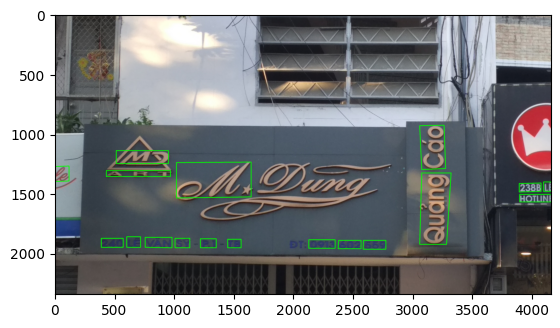

In [141]:
show_image = image.copy()
for box in orig_boxes: 
    draw_polygon(show_image, box, thickness=5, color=(0, 255, 0))

plt.imshow(show_image)
plt.show()